<a href="https://colab.research.google.com/github/RupamGhosh-loading/NewDelhiWeatherInsights/blob/main/New_Delhi_Weather_insight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/NewDelhiWeatherInsights(2010-2023).csv')
print(df.head())

   Date  Year  Month  Max Temperature  Avg Temperature  Min Temperature  \
0     1  2010      1               70             55.7               45   
1     2  2010      1               59             50.6               46   
2     3  2010      1               57             52.8               48   
3     4  2010      1               55             51.0               48   
4     5  2010      1               63             53.1               46   

   Max Dew Point  Avg Dew Point  Min Dew Point  Max Humidity  Avg Humidity  \
0             52           47.5             41           100          77.5   
1             54           49.6             46           100          96.7   
2             57           52.1             48           100          97.3   
3             50           48.4             48           100          91.9   
4             52           47.9             46           100          85.1   

   Min Humidity  Max Wind Speed  Avg Wind Speed  Min Wind Speed  Max Pressure  \

In [ ]:
df['FullDate'] = pd.to_datetime(df[['Year', 'Month', 'Date']].astype(str).agg('-'.join, axis=1), format='%Y-%m-%d')
df = df.set_index('FullDate')
df = df.sort_index()

print(df.head())

            Date  Year  Month  Max Temperature  Avg Temperature  \
FullDate                                                          
2010-01-01     1  2010      1               70             55.7   
2010-01-02     2  2010      1               59             50.6   
2010-01-03     3  2010      1               57             52.8   
2010-01-04     4  2010      1               55             51.0   
2010-01-05     5  2010      1               63             53.1   

            Min Temperature  Max Dew Point  Avg Dew Point  Min Dew Point  \
FullDate                                                                   
2010-01-01               45             52           47.5             41   
2010-01-02               46             54           49.6             46   
2010-01-03               48             57           52.1             48   
2010-01-04               48             50           48.4             48   
2010-01-05               46             52           47.9             46  

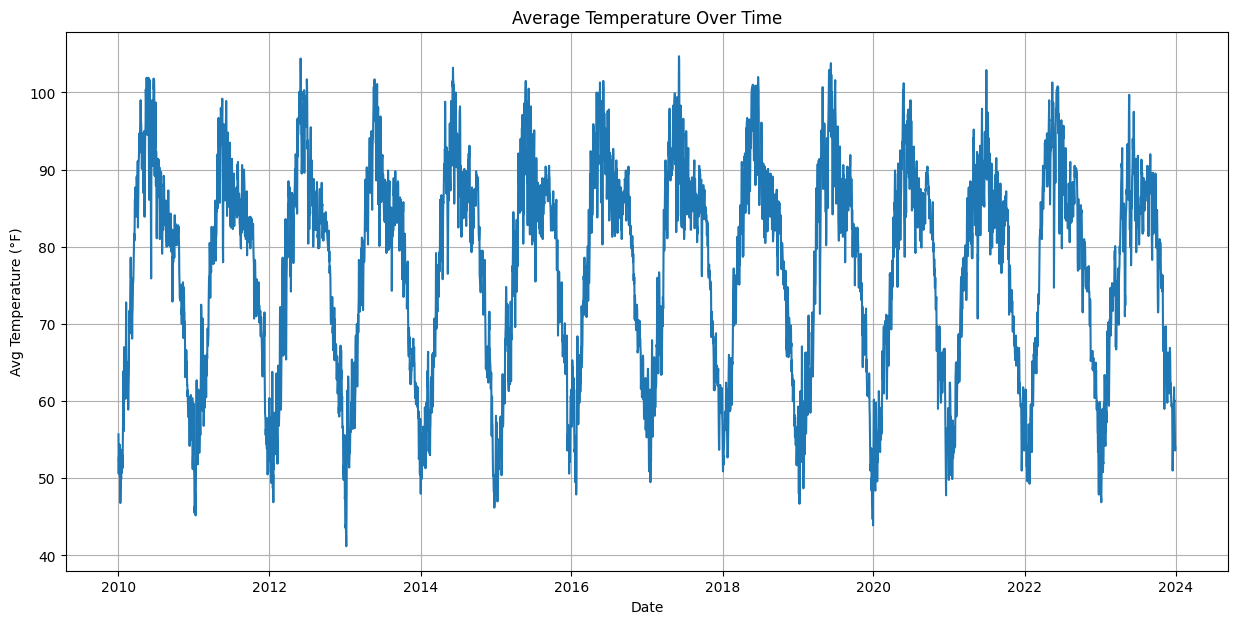

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x=df.index, y='Avg Temperature')
plt.title('Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.grid(True)
plt.show()

### Checking for Stationarity

Before applying ARIMA models, it's essential to check if the time series data is **stationary**. A stationary time series is one whose statistical properties (like mean, variance, and autocorrelation) do not change over time. Many time series models, including ARIMA, assume stationarity.

We can check for stationarity both visually (by observing trends or seasonality in plots) and statistically. A common statistical test is the **Augmented Dickey-Fuller (ADF) test**.

**Augmented Dickey-Fuller (ADF) Test:**

*   **Null Hypothesis (H0):** The time series has a unit root, meaning it is non-stationary.
*   **Alternative Hypothesis (H1):** The time series does not have a unit root, meaning it is stationary.

If the p-value from the ADF test is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude that the series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on 'Avg Temperature'
result = adfuller(df['Avg Temperature'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result[1] <= 0.05:
    print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The time series is likely non-stationary (p-value > 0.05). Differencing may be required.")

ADF Statistic: -5.722358
p-value: 0.000001
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

Conclusion: The time series is likely stationary (p-value <= 0.05).


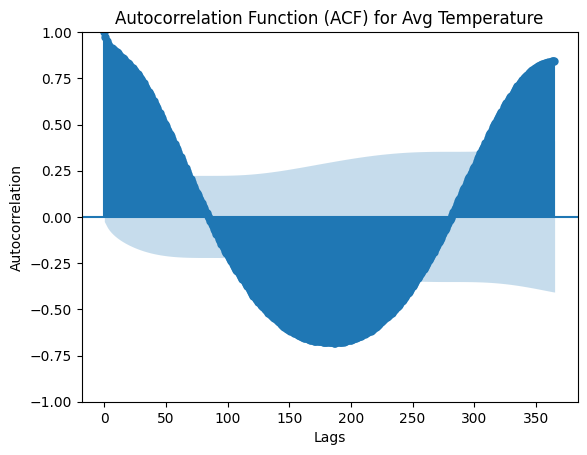

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF plot
fig_acf = plot_acf(df['Avg Temperature'], lags=365)
plt.title('Autocorrelation Function (ACF) for Avg Temperature')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

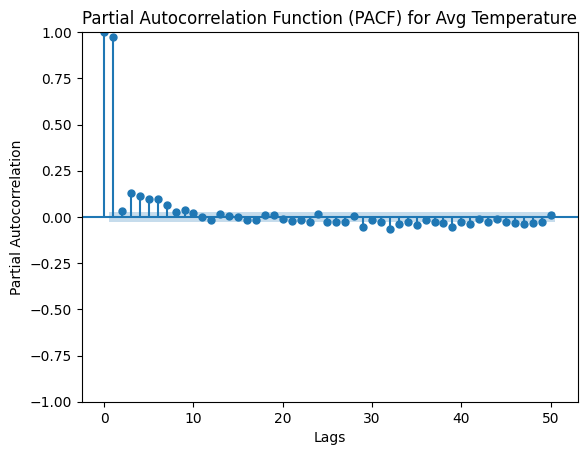

In [ ]:
# PACF plot
fig_pacf = plot_pacf(df['Avg Temperature'], lags=50)
plt.title('Partial Autocorrelation Function (PACF) for Avg Temperature')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 29.4 MB/s eta 0:00:00


In [ ]:
from scipy.signal import periodogram

freqs, power = periodogram(df['Avg Temperature'])
dominant_freq = freqs[power.argmax()]
season_length = int(1 / dominant_freq)

print(season_length)

365


In [ ]:
# Ensure the DataFrame has a complete daily frequency
# This fills any missing dates with NaN values for 'Avg Temperature'
df = df.asfreq('D')

In [ ]:
# Drop rows with NaN values in 'Avg Temperature' column
df.dropna(subset=['Avg Temperature'], inplace=True)

In [ ]:
import numpy as np

# Create a continuous daily series for 'Avg Temperature' by resampling and interpolating
# This fills any missing dates with NaNs and then interpolates them.
y_continuous = df['Avg Temperature'].resample('D').mean() # Use .mean() or .first() etc., as appropriate
y_continuous = y_continuous.interpolate(method='linear') # Interpolate NaNs linearly

# Verify that there are no NaNs left and the index is continuous
print(f"NaNs in continuous series after interpolation: {y_continuous.isnull().sum()}")
print(f"Length of continuous series: {len(y_continuous)}")
print(f"Start date: {y_continuous.index.min()}, End date: {y_continuous.index.max()}")

# Check if the index is now perfectly daily and continuous
expected_date_range = pd.date_range(start=y_continuous.index.min(), end=y_continuous.index.max(), freq='D')
print(f"Is the index perfectly continuous daily: {y_continuous.index.equals(expected_date_range)}")

NaNs in continuous series after interpolation: 0
Length of continuous series: 5113
Start date: 2010-01-01 00:00:00, End date: 2023-12-31 00:00:00
Is the index perfectly continuous daily: True


### Train-Test Split

We will now split our continuous `Avg Temperature` series and its corresponding Fourier features into training and testing sets. The model will be fit on the training data and then evaluated on the unseen test data to assess its out-of-sample forecasting capability.

In [ ]:
from pmdarima.preprocessing import FourierFeaturizer
import pandas as pd

# 1. Generate Fourier features from y_continuous
fourier_transformer = FourierFeaturizer(m=365, k=5)
# Correctly unpack the tuple returned by fit_transform. The Fourier features are the second element.
_, X_exog = fourier_transformer.fit_transform(y_continuous)

# 2. Explicitly ensure the index of the generated Fourier features is aligned with y_continuous.
# This helps statsmodels correctly align endog and exog.
# By assigning y_continuous.index, we ensure both date values and frequency are consistent.
X_exog.index = y_continuous.index

# Define the split point for train and test sets (e.g., last 365 days for test)
n_test_steps = 365

train = y_continuous[:-n_test_steps]
test = y_continuous[-n_test_steps:]

# Split exogenous features accordingly
X_exog_train = X_exog.iloc[:-n_test_steps]
X_exog_test = X_exog.iloc[-n_test_steps:]

print(f"Train set length: {len(train)}")
print(f"Test set length: {len(test)}")
print(f"X_exog_train length: {len(X_exog_train)}")
print(f"X_exog_test length: {len(X_exog_test)}")

Train set length: 4748
Test set length: 365
X_exog_train length: 4748
X_exog_test length: 365


Now that we have a continuous `Avg Temperature` series, we can proceed with fitting the `pmdarima` pipeline.

In [ ]:
from pmdarima.arima import AutoARIMA

# Fit AutoARIMA with exogenous features on the TRAINING DATA
# Setting error_action='ignore' means AutoARIMA will skip models that fail to fit
# (e.g., due to numerical issues) rather than stopping the entire search.
model = AutoARIMA(seasonal=False,
                  suppress_warnings=True,
                  error_action="ignore",
                  trace=False, # Set to True for verbose output during search
                  n_jobs=-1) # Use all available cores for faster search

model.fit(y=train, X=X_exog_train)

print("AutoARIMA model fitted successfully with Fourier features on training data.")

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


AutoARIMA model fitted successfully with Fourier features on training data.


The model has been successfully fitted on the training data, and predictions have been made on the unseen test set.

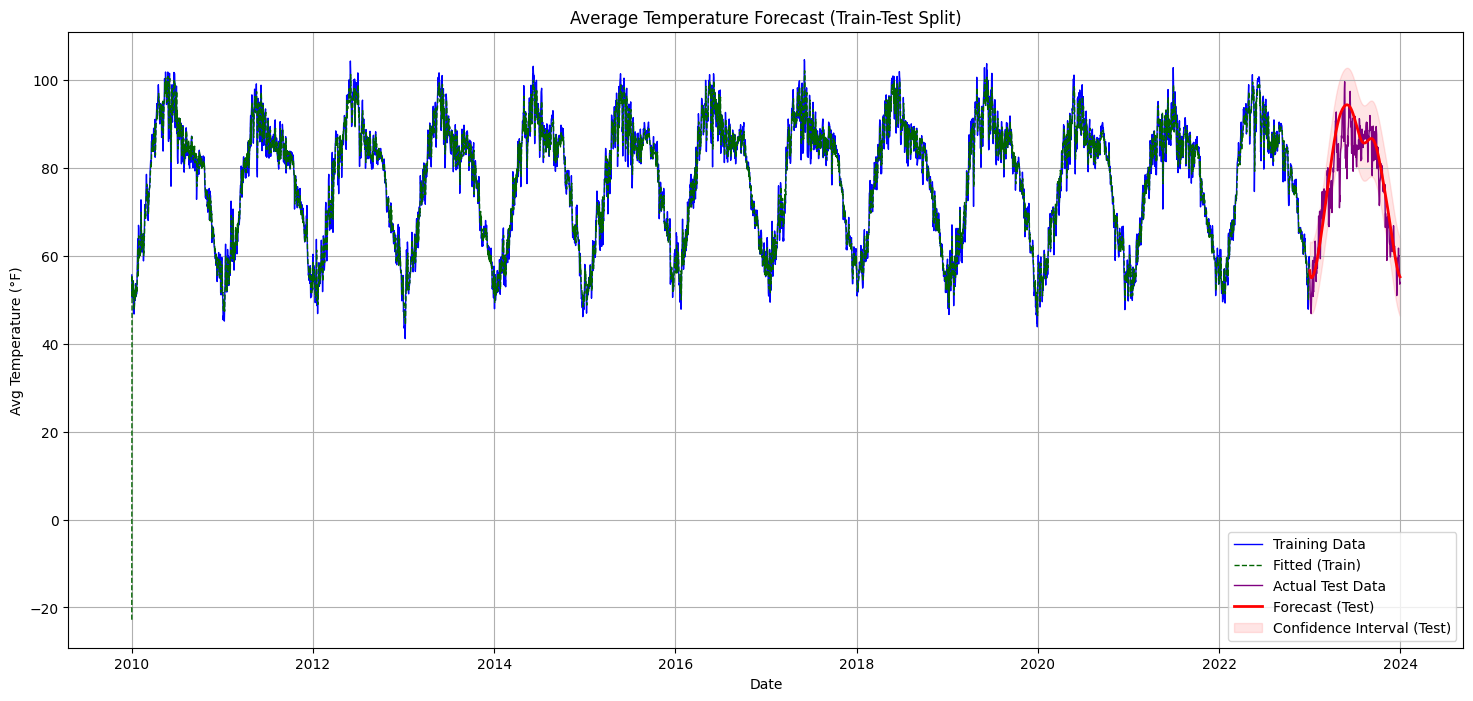

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the in-sample predictions from the fitted model on the training data
train_predictions = model.predict_in_sample(X=X_exog_train)

# Make predictions for the test set
test_forecast, test_conf_int = model.predict(n_periods=len(test), X=X_exog_test, return_conf_int=True)
test_forecast_series = pd.Series(test_forecast, index=test.index, name='Forecast')
test_conf_int_df = pd.DataFrame(test_conf_int, index=test.index, columns=['Lower Bound', 'Upper Bound'])

plt.figure(figsize=(18, 8))

# Plot training data
sns.lineplot(x=train.index, y=train, label='Training Data', color='blue', linewidth=1)
# Plot in-sample predictions for training data
sns.lineplot(x=train_predictions.index, y=train_predictions, label='Fitted (Train)', color='darkgreen', linestyle='--', linewidth=1)

# Plot actual test data
sns.lineplot(x=test.index, y=test, label='Actual Test Data', color='purple', linewidth=1)
# Plot forecast on test data
sns.lineplot(x=test_forecast_series.index, y=test_forecast_series, label='Forecast (Test)', color='red', linewidth=2)

# Plot confidence intervals for the test forecast
plt.fill_between(test_conf_int_df.index,
                 test_conf_int_df['Lower Bound'],
                 test_conf_int_df['Upper Bound'],
                 color='red', alpha=0.1, label='Confidence Interval (Test)')

plt.title('Average Temperature Forecast (Train-Test Split)')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True)
plt.show()

The plot now clearly shows:

Training Data (blue line)
Fitted (Train) values (dark green dashed line), representing how well the model captured patterns in the training data.
Actual Test Data (purple line), the unseen data the model is forecasting.
Forecast (Test) (red line), the model's predictions for the test period.
Confidence Interval (Test) (red shaded area), indicating the uncertainty around the forecasts.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE for the test set
rmse = np.sqrt(mean_squared_error(test, test_forecast_series))
print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.2f}")

Root Mean Squared Error (RMSE) on Test Set: 5.37


Root Mean Squared Error (RMSE) on Test Set: 5.37: This indicates that, on average, the model's predictions for the test set deviate from the actual values by about 5.37 units (°F). This is a good general measure of the magnitude of the errors.

In [ ]:
# Calculate MAPE for the test set
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(test, test_forecast_series)
print(f"Mean Absolute Percentage Error (MAPE) on Test Set: {mape:.2f}%")

Mean Absolute Percentage Error (MAPE) on Test Set: 5.56%


Mean Absolute Percentage Error (MAPE) on Test Set: 5.56%: This means that, on average, the forecast differs from the actual value by about 5.56% of the actual value.

In [ ]:
print(model.summary()) # This summary is for the model fitted on the training data

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4748
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -11618.006
Date:                Sun, 03 May 2026   AIC                          23264.011
Time:                        14:18:12   BIC                          23354.525
Sample:                    01-01-2010   HQIC                         23295.818
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
FOURIER_S365-0    -0.6421      0.244     -2.626      0.009      -1.121      -0.163
FOURIER_C365-0   -17.1163      0.237    -72.112      0.000     -17.581     -16.651
FOURIER_S365-1    -3.7881      0.217

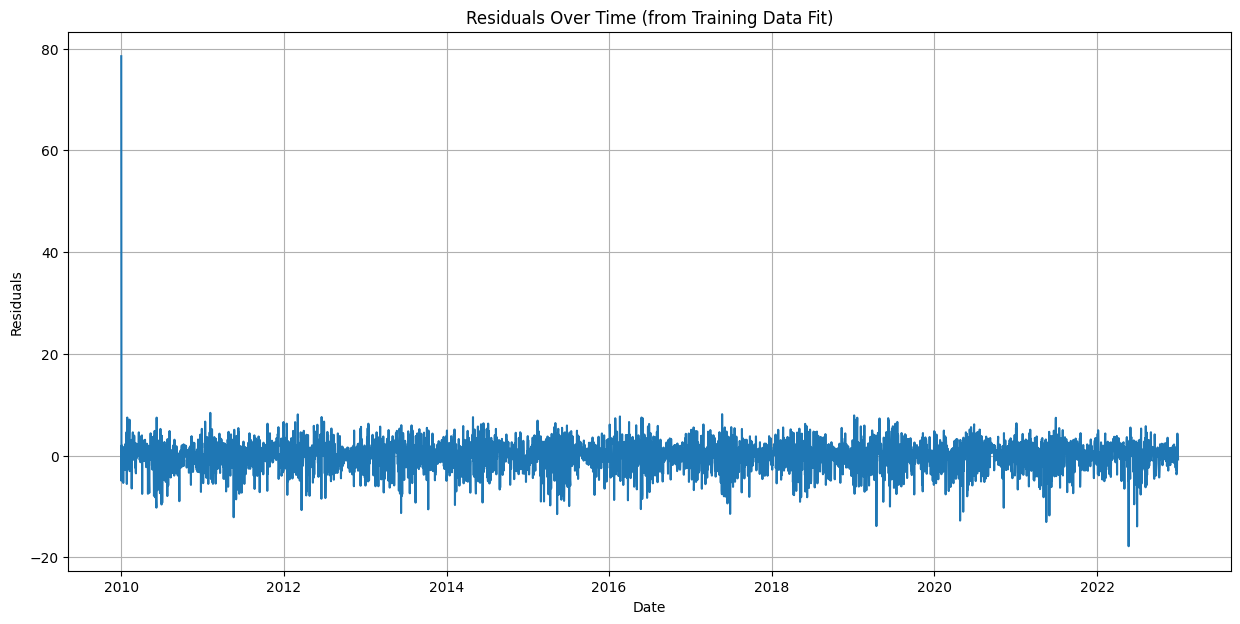

In [ ]:
residuals = train - train_predictions

plt.figure(figsize=(15, 7))
sns.lineplot(x=residuals.index, y=residuals)
plt.title('Residuals Over Time (from Training Data Fit)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

The residuals are now calculated based on the difference between the training data and the model's in-sample predictions on the training data. This plot helps assess if the model has captured all the underlying patterns from the data it was trained on.

Next, let's examine the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of the residuals. For white noise, we expect to see no significant autocorrelations at any lag, except possibly at lag 0.

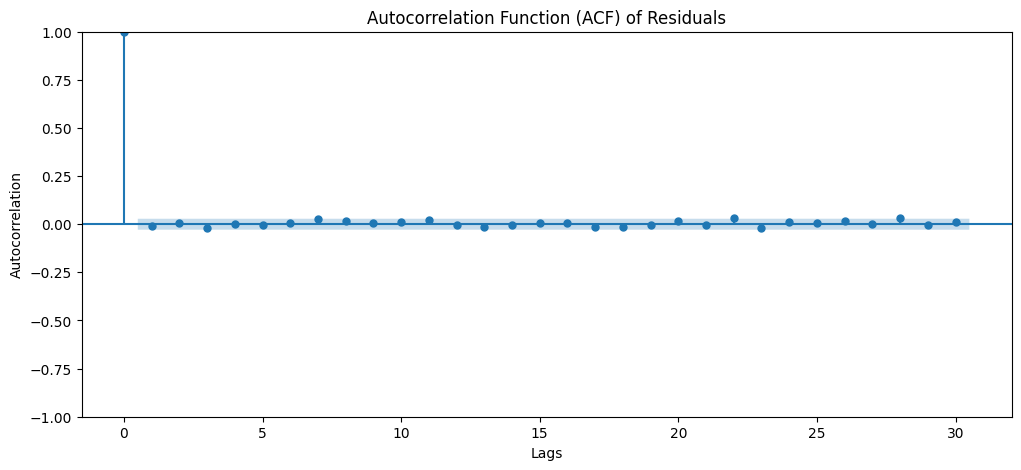

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF plot of residuals
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(residuals, lags=30, ax=ax)
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

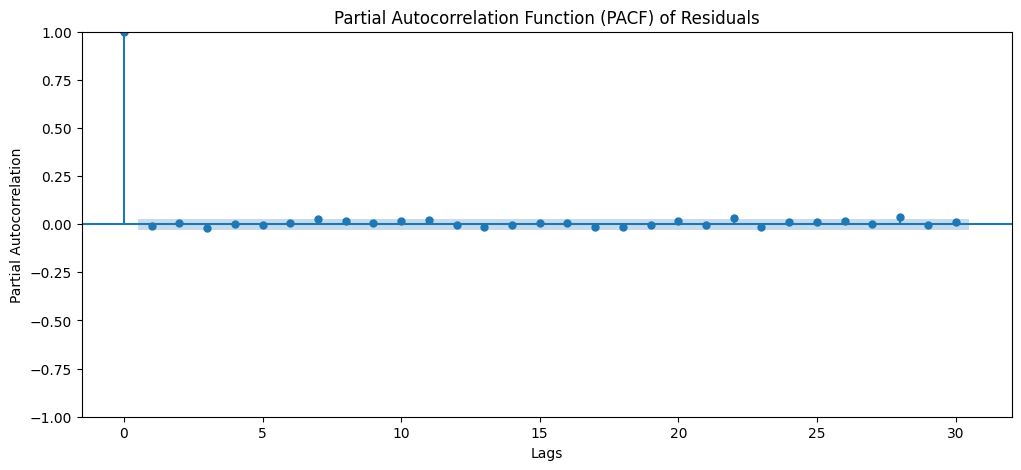

In [ ]:
# PACF plot of residuals
fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(residuals, lags=30, ax=ax)
plt.title('Partial Autocorrelation Function (PACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

If the residuals are white noise, their values should be randomly scattered around zero, and their ACF and PACF plots should show no significant correlations after lag 0.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test
# lags: number of lags to test for autocorrelation
# boxpierce: return Box-Pierce test statistic and p-value (default is True)
ljung_box_results = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)

print("Ljung-Box Test Results on Residuals:")
print(ljung_box_results)

# Interpretation (example for lag 10)
p_value_lag_10 = ljung_box_results.loc[10, 'lb_pvalue']
if p_value_lag_10 > 0.05:
    print(f"\nAt lag 10, the p-value ({p_value_lag_10:.3f}) is > 0.05. We fail to reject the null hypothesis. This suggests that there is no significant autocorrelation in the residuals at lag 10, supporting the white noise assumption.")
else:
    print(f"\nAt lag 10, the p-value ({p_value_lag_10:.3f}) is <= 0.05. We reject the null hypothesis. This suggests that there is significant autocorrelation in the residuals at lag 10, indicating they may not be white noise.")

Ljung-Box Test Results on Residuals:
      lb_stat  lb_pvalue
10   8.474923   0.582551
20  14.734811   0.791375
30  29.866804   0.472491

At lag 10, the p-value (0.583) is > 0.05. We fail to reject the null hypothesis. This suggests that there is no significant autocorrelation in the residuals at lag 10, supporting the white noise assumption.


### Forecasting Future Temperatures

Now that we have a well-fitted model and its residuals have been confirmed to be white noise, we can use it to forecast future temperatures. We will predict the average temperature for the next year (365 days) and visualize these forecasts.

In [ ]:
import numpy as np
import pandas as pd
from pmdarima.arima import AutoARIMA

# 1. Re-generate all Fourier features for the full historical range
def get_fourier_features(index, m, k):
    t = (index - pd.Timestamp("2010-01-01")).days.values
    features = pd.DataFrame(index=index)
    for i in range(k):
        features[f'FOURIER_S{m}-{i}'] = np.sin(2 * np.pi * (i + 1) * t / m)
        features[f'FOURIER_C{m}-{i}'] = np.cos(2 * np.pi * (i + 1) * t / m)
    return features

X_exog_full = get_fourier_features(y_continuous.index, m=365, k=5)

# 2. Refit the model on the ENTIRE continuous dataset for better future forecasting
final_model = AutoARIMA(seasonal=False, suppress_warnings=True, error_action="ignore", n_jobs=-1)
final_model.fit(y=y_continuous, X=X_exog_full)

# 3. Generate future features and forecast
n_forecast_steps = 365
last_date = y_continuous.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast_steps, freq='D')

X_exog_future = get_fourier_features(future_dates, m=365, k=5)

forecast, conf_int = final_model.predict(n_periods=n_forecast_steps, X=X_exog_future, return_conf_int=True)
forecast_series = pd.Series(forecast, index=future_dates, name='Forecast')
conf_int_df = pd.DataFrame(conf_int, index=future_dates, columns=['Lower Bound', 'Upper Bound'])

print("Model refitted on full data and future forecast generated successfully.")
display(forecast_series.head())

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Model refitted on full data and future forecast generated successfully.


,Forecast
2024-01-01,53.955312
2024-01-02,53.867622
2024-01-03,53.792165
2024-01-04,53.735356
2024-01-05,53.697143


In [ ]:
# Check for nulls and non-numeric values in the future exogenous features
print(f"Total NaNs in X_exog_future: {X_exog_future.isnull().sum().sum()}")
print(f"Data types in X_exog_future:\n{X_exog_future.dtypes}")

# Display the first few rows to verify the values
display(X_exog_future.head())

Total NaNs in X_exog_future: 0
Data types in X_exog_future:
FOURIER_S365-0    float64
FOURIER_C365-0    float64
FOURIER_S365-1    float64
FOURIER_C365-1    float64
FOURIER_S365-2    float64
FOURIER_C365-2    float64
FOURIER_S365-3    float64
FOURIER_C365-3    float64
FOURIER_S365-4    float64
FOURIER_C365-4    float64
dtype: object


,FOURIER_S365-0,FOURIER_C365-0,FOURIER_S365-1,FOURIER_C365-1,FOURIER_S365-2,FOURIER_C365-2,FOURIER_S365-3,FOURIER_C365-3,FOURIER_S365-4,FOURIER_C365-4
2024-01-01,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848
2024-01-02,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317
2024-01-03,0.085965,0.996298,0.171293,0.985220,0.255353,0.966848,0.337523,0.941317,0.417194,0.908818
2024-01-04,0.103102,0.994671,0.205104,0.978740,0.304921,0.952378,0.401488,0.915864,0.493776,0.869589
2024-01-05,0.120208,0.992749,0.238673,0.971100,0.353676,0.935368,0.463550,0.886071,0.566702,0.823923


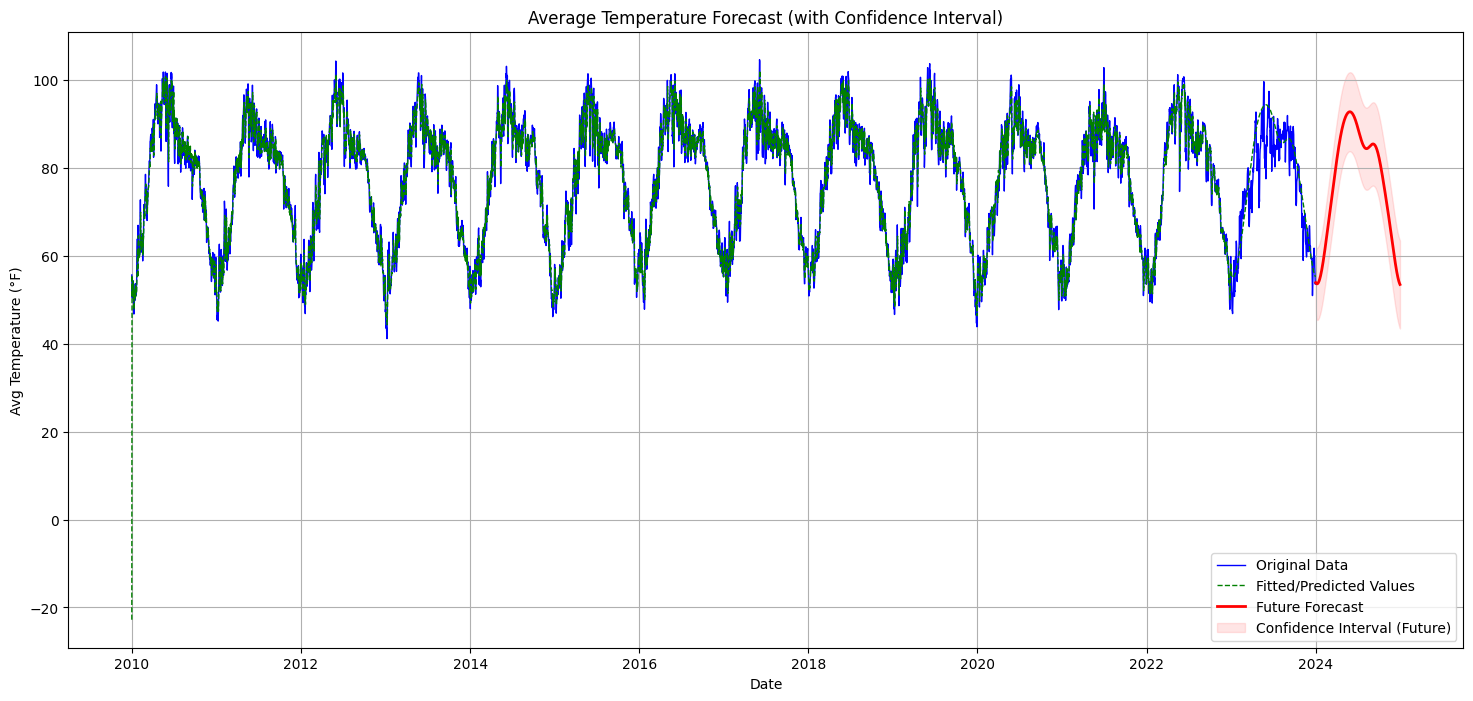

In [ ]:
plt.figure(figsize=(18, 8))

# Combine in-sample predictions and test forecasts for a continuous 'Fitted Values' line
all_fitted_predictions = pd.concat([train_predictions, test_forecast_series])

# Plot original data (up to the end of the test set)
sns.lineplot(x=y_continuous.index, y=y_continuous, label='Original Data', color='blue', linewidth=1)

# Plot fitted values (in-sample for train + out-of-sample for test)
sns.lineplot(x=all_fitted_predictions.index, y=all_fitted_predictions, label='Fitted/Predicted Values', color='green', linestyle='--', linewidth=1)

# Plot future forecast
sns.lineplot(x=forecast_series.index, y=forecast_series, label='Future Forecast', color='red', linewidth=2)

# Plot confidence intervals for the future forecast
plt.fill_between(conf_int_df.index,
                 conf_int_df['Lower Bound'],
                 conf_int_df['Upper Bound'],
                 color='red', alpha=0.1, label='Confidence Interval (Future)')

plt.title('Average Temperature Forecast (with Confidence Interval)')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True)
plt.show()

### Seasonal Comparison: Forecasted vs. Historical Average Temperatures

To understand how our forecast compares to typical seasonal patterns, we'll calculate the historical average temperature for each day of the year across all available data and plot it against our forecasted values.

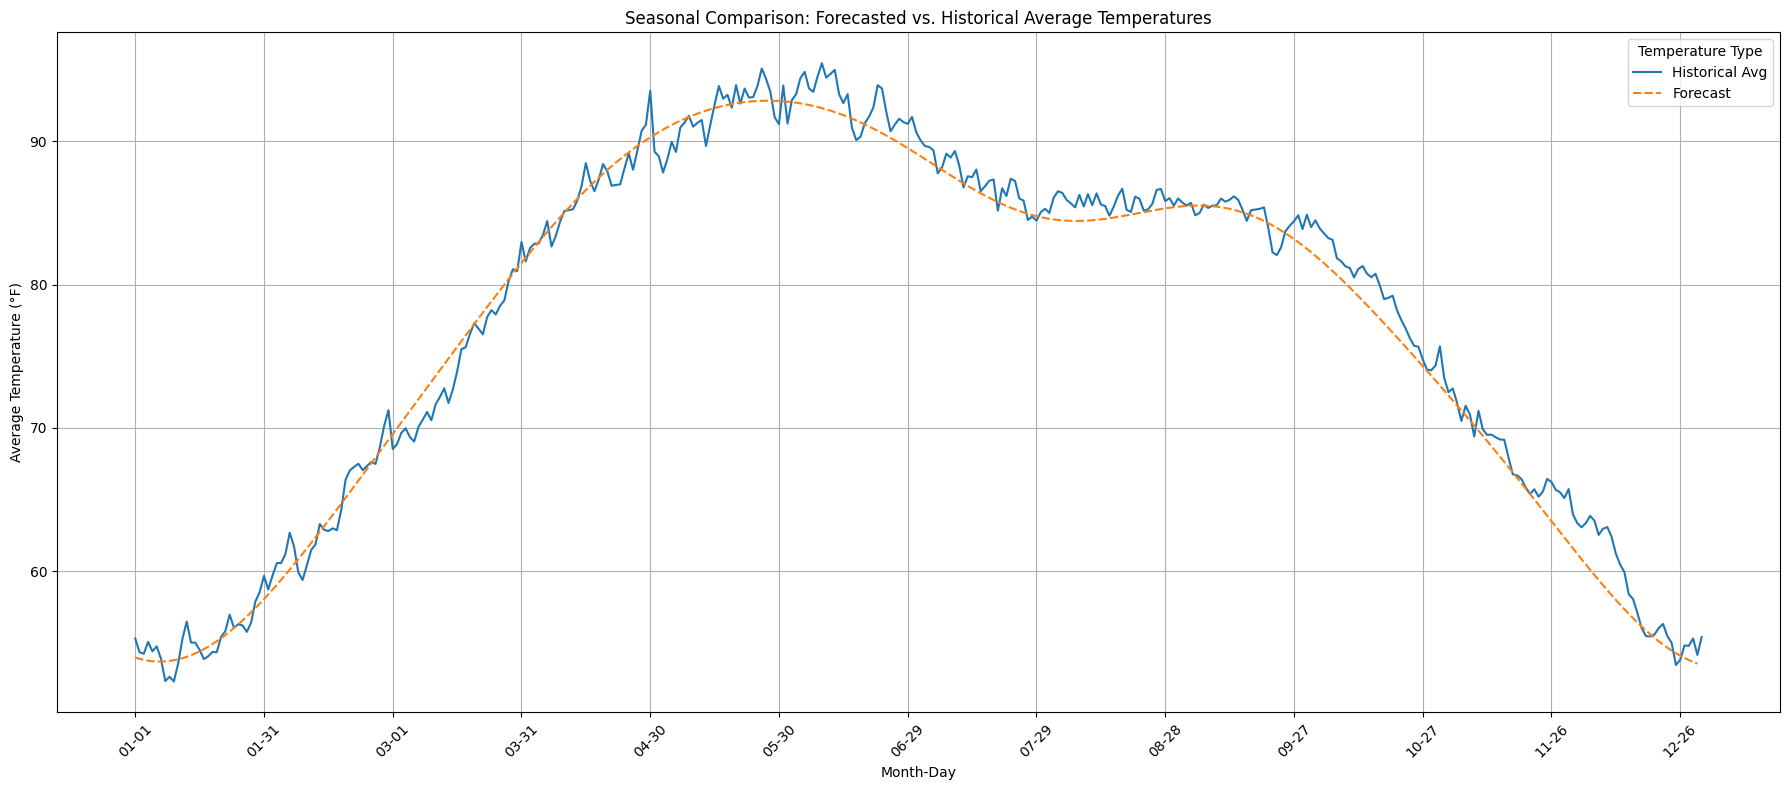

In [ ]:
# 1. Prepare historical seasonal data
historical_data_for_seasonal_avg = pd.DataFrame({'Avg Temperature': y_continuous})
historical_data_for_seasonal_avg['MonthDay'] = historical_data_for_seasonal_avg.index.strftime('%m-%d')
historical_seasonal_avg = historical_data_for_seasonal_avg.groupby('MonthDay')['Avg Temperature'].mean()

# 2. Prepare forecasted data
forecast_data_for_seasonal_avg = pd.DataFrame({'Forecast Temp': forecast_series})
forecast_data_for_seasonal_avg['MonthDay'] = forecast_data_for_seasonal_avg.index.strftime('%m-%d')
# Group by MonthDay to handle any potential alignment issues and ensure a matching index
forecast_seasonal_avg = forecast_data_for_seasonal_avg.groupby('MonthDay')['Forecast Temp'].mean()

# 3. Create a combined DataFrame for plotting
combined_seasonal_df = pd.DataFrame({
    'Historical Avg': historical_seasonal_avg,
    'Forecast': forecast_seasonal_avg
})

# 4. Plot
# Sort by MonthDay for correct plotting order
combined_seasonal_df = combined_seasonal_df.sort_index()

plt.figure(figsize=(18, 8))
sns.lineplot(data=combined_seasonal_df)
plt.title('Seasonal Comparison: Forecasted vs. Historical Average Temperatures')
plt.xlabel('Month-Day')
plt.ylabel('Average Temperature (°F)')
plt.xticks(rotation=45)

# Adjust x-axis ticks to show fewer labels for readability
num_labels = 12
step = max(1, len(combined_seasonal_df) // num_labels)
plt.gca().set_xticks(range(0, len(combined_seasonal_df), step))
plt.gca().set_xticklabels(combined_seasonal_df.index[::step])

plt.grid(True)
plt.legend(title='Temperature Type')
plt.tight_layout()
plt.show()

### Time Series Decomposition

Time series decomposition is a technique that breaks down a time series into several components, typically:

*   **Trend:** The long-term progression of the series.
*   **Seasonal:** Patterns that repeat over a fixed period (e.g., daily, weekly, yearly).
*   **Residual (or Irregular):** The random variation left after accounting for the trend and seasonal components.

This helps in understanding the underlying structure of the data and can guide further modeling decisions.

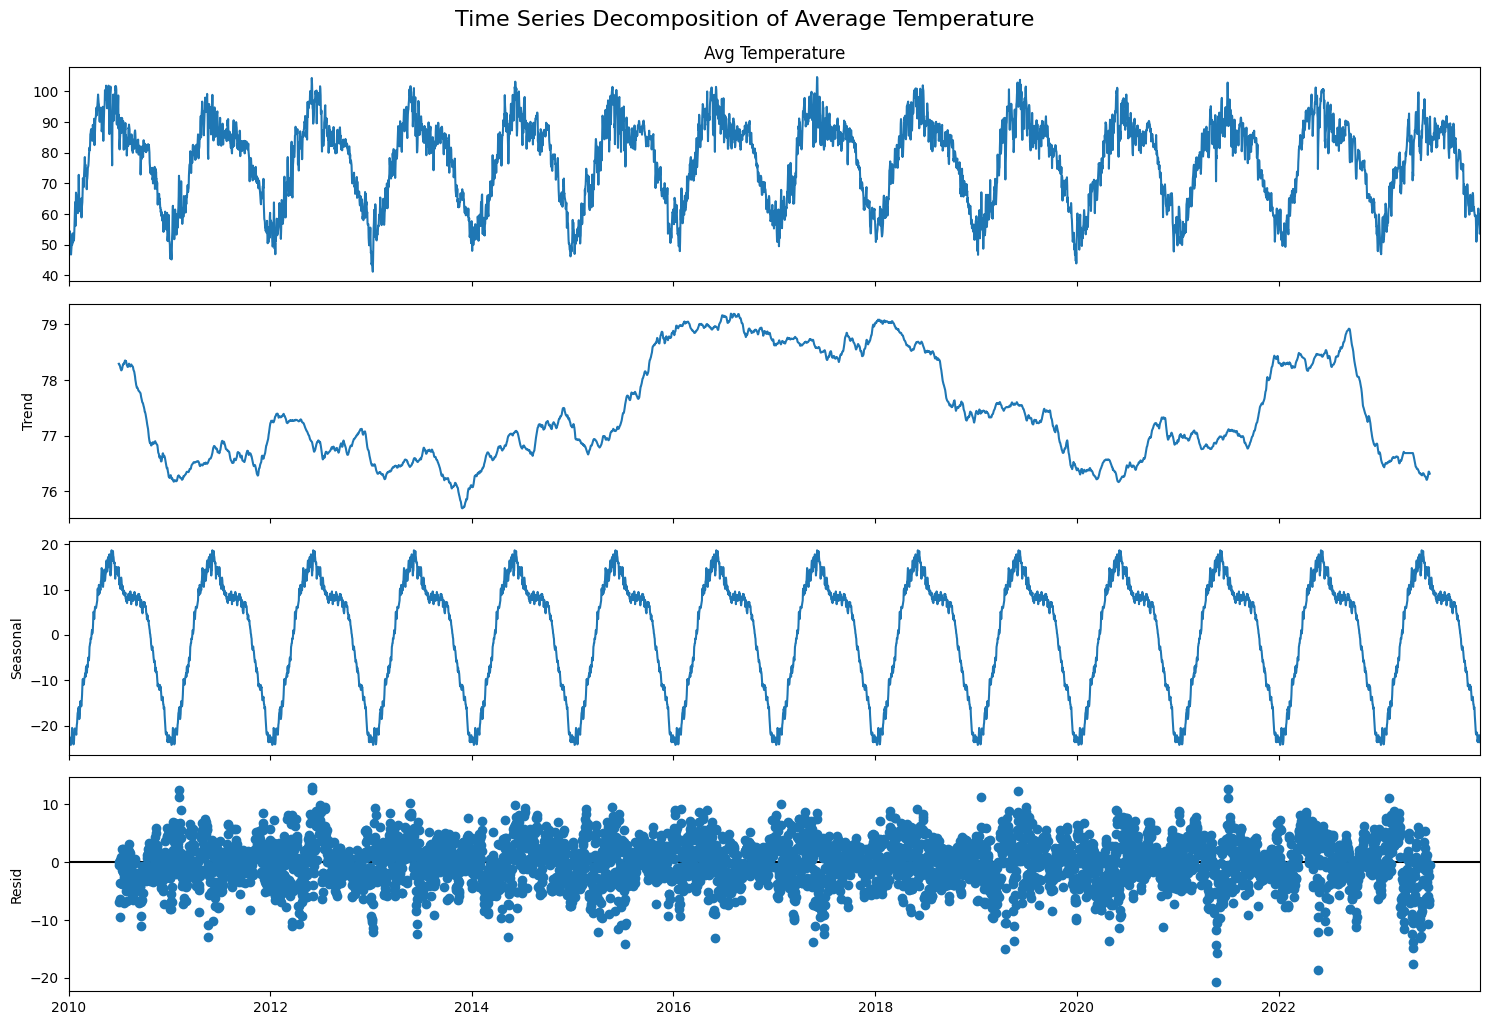

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform seasonal decomposition
# The 'model' parameter can be 'additive' or 'multiplicative'.
# For temperature data, 'additive' is often more appropriate as seasonal fluctuations
# tend to be constant in magnitude rather than proportional to the trend.
# The 'period' should match the detected season length.
decomposition = seasonal_decompose(y_continuous, model='additive', period=season_length)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.tight_layout()
plt.suptitle('Time Series Decomposition of Average Temperature', y=1.02, fontsize=16)
plt.show()



* Seasonal fluctuations are constant in magnitude.
* They do not grow or shrink with time.
* Pattern is stable across years.

Trend → slowly varying.
Seasonality → strong, stable yearly cycle.
The time series exhibits strong deterministic seasonal behavior with constant amplitude, making an additive model appropriate.





In [ ]:
#ETS model with seasonality=7
train = y_continuous[:-365]
test = y_continuous[-365:]
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train,
    trend='add',
    damped_trend=True, # Added damped trend
    seasonal='add',
    seasonal_periods=7
)

ets_fit = ets_model.fit()

In [ ]:
print(ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:          Avg Temperature   No. Observations:                 4748
Model:             ExponentialSmoothing   SSE                          43171.526
Optimized:                         True   AIC                          10505.009
Trend:                         Additive   BIC                          10582.595
Seasonal:                      Additive   AICC                         10505.098
Seasonal Periods:                     7   Date:                 Sun, 03 May 2026
Box-Cox:                          False   Time:                         14:22:37
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9217252                alpha                 True
smoothing_trend          

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Make predictions for the test set using the ETS model
ets_test_forecast = ets_fit.predict(start=len(train), end=len(train) + len(test) - 1)
ets_test_forecast_series = pd.Series(ets_test_forecast, index=test.index, name='ETS Forecast')

# Calculate RMSE for the ETS model on the test set
ets_rmse = np.sqrt(mean_squared_error(test, ets_test_forecast_series))
print(f"ETS Root Mean Squared Error (RMSE) on Test Set: {ets_rmse:.2f}")

# Calculate MAPE for the ETS model on the test set
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ets_mape = mean_absolute_percentage_error(test, ets_test_forecast_series)
print(f"ETS Mean Absolute Percentage Error (MAPE) on Test Set: {ets_mape:.2f}%")

ETS Root Mean Squared Error (RMSE) on Test Set: 22.00
ETS Mean Absolute Percentage Error (MAPE) on Test Set: 23.43%


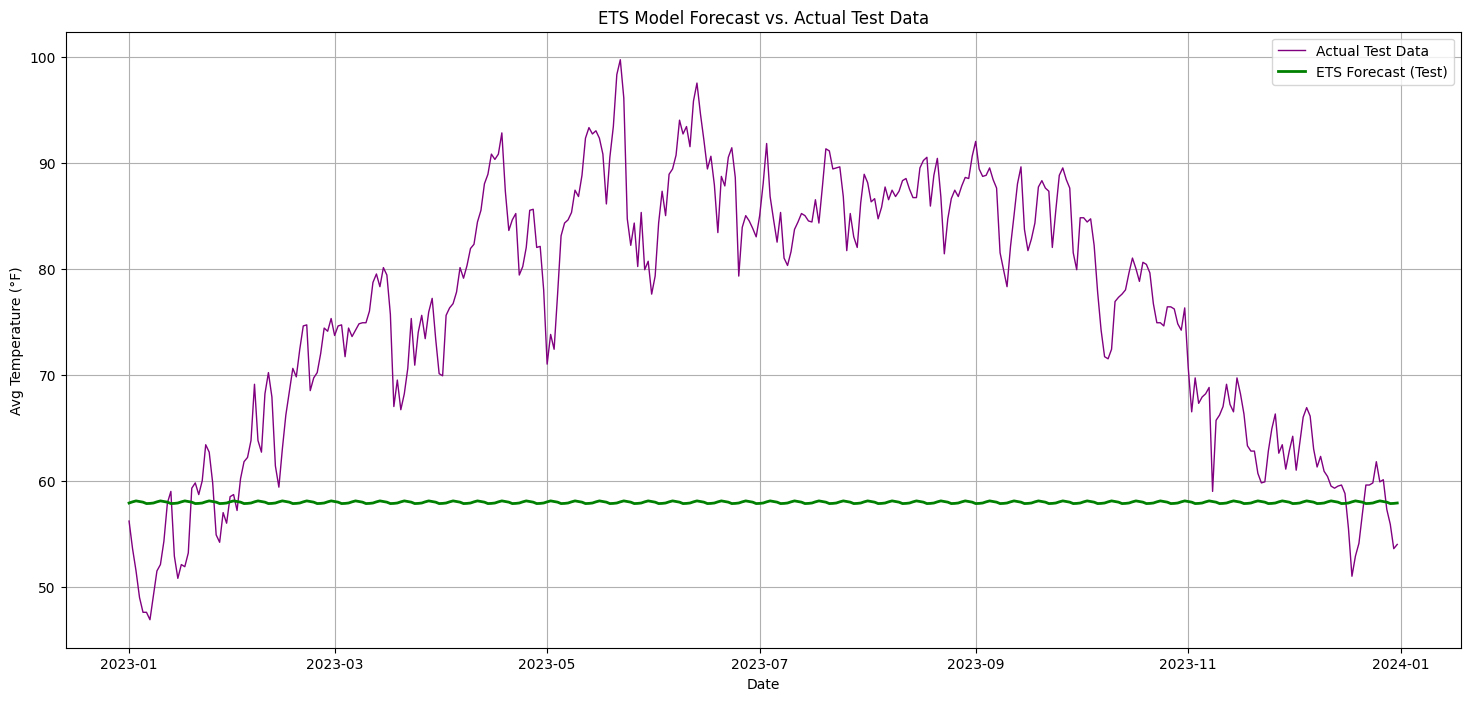

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))

# Plot actual test data
sns.lineplot(x=test.index, y=test, label='Actual Test Data', color='purple', linewidth=1)

# Plot ETS forecast on test data
sns.lineplot(x=ets_test_forecast_series.index, y=ets_test_forecast_series, label='ETS Forecast (Test)', color='green', linestyle='-', linewidth=2)

plt.title('ETS Model Forecast vs. Actual Test Data')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#ETS model with 365 seasonality
train = y_continuous[:-365]
test = y_continuous[-365:]
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train,
    trend='add',
    damped_trend=True, # Added damped trend
    seasonal='add',
    seasonal_periods=365
)

ets_fit = ets_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Make predictions for the test set using the ETS model
ets_test_forecast = ets_fit.predict(start=len(train), end=len(train) + len(test) - 1)
ets_test_forecast_series = pd.Series(ets_test_forecast, index=test.index, name='ETS Forecast')

# Calculate RMSE for the ETS model on the test set
ets_rmse = np.sqrt(mean_squared_error(test, ets_test_forecast_series))
print(f"ETS Root Mean Squared Error (RMSE) on Test Set: {ets_rmse:.2f}")

# Calculate MAPE for the ETS model on the test set
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ets_mape = mean_absolute_percentage_error(test, ets_test_forecast_series)
print(f"ETS Mean Absolute Percentage Error (MAPE) on Test Set: {ets_mape:.2f}%")

ETS Root Mean Squared Error (RMSE) on Test Set: 9.06
ETS Mean Absolute Percentage Error (MAPE) on Test Set: 10.12%


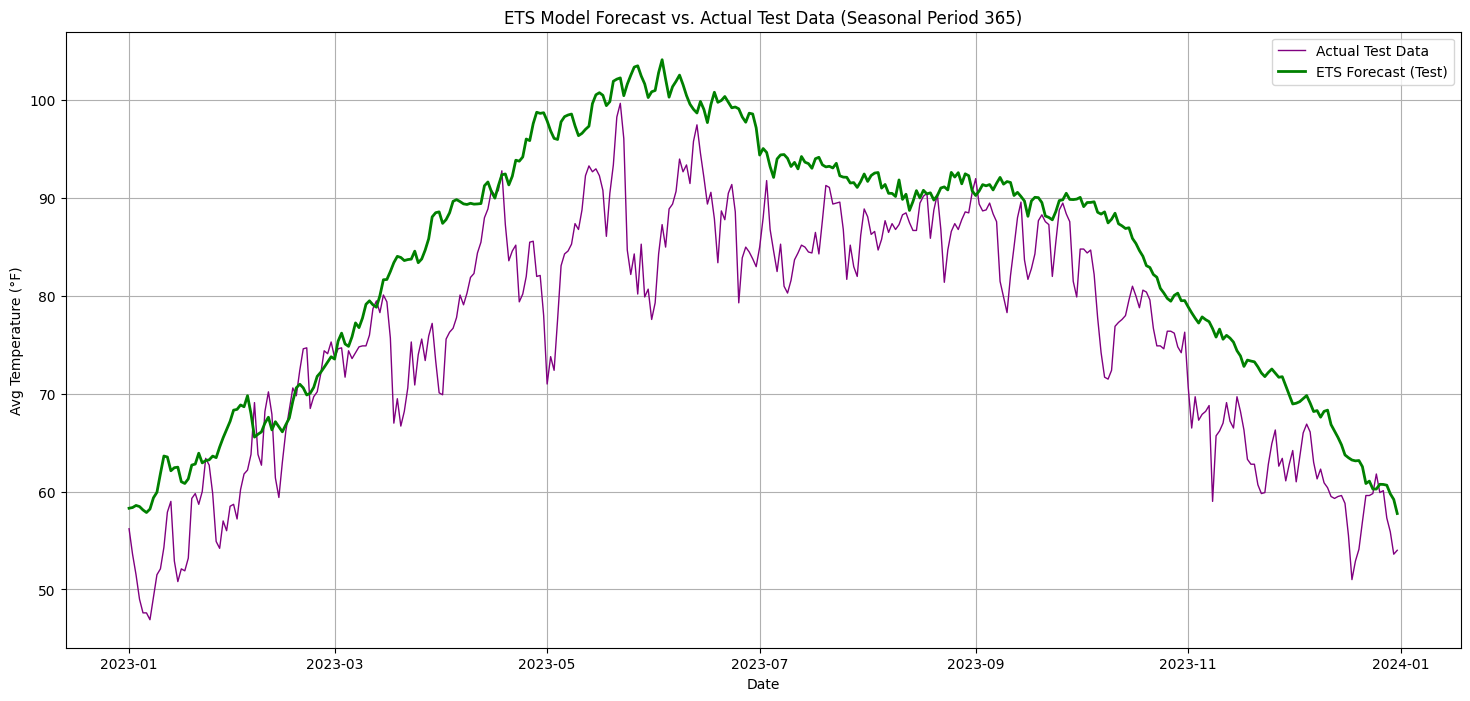

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))

# Plot actual test data
sns.lineplot(x=test.index, y=test, label='Actual Test Data', color='purple', linewidth=1)

# Plot ETS forecast on test data
sns.lineplot(x=ets_test_forecast_series.index, y=ets_test_forecast_series, label='ETS Forecast (Test)', color='green', linestyle='-', linewidth=2)

plt.title('ETS Model Forecast vs. Actual Test Data (Seasonal Period 365)')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True)
plt.show()

### SARIMA Modeling (Monthly Seasonality)

We will now apply a Seasonal Autoregressive Integrated Moving Average (SARIMA) model with the parameters $(0,0,1) \times (1,0,1)_{30}$ to capture a monthly cycle.

SARIMA(0,0,1)(1,0,1)[30] RMSE: 26.04


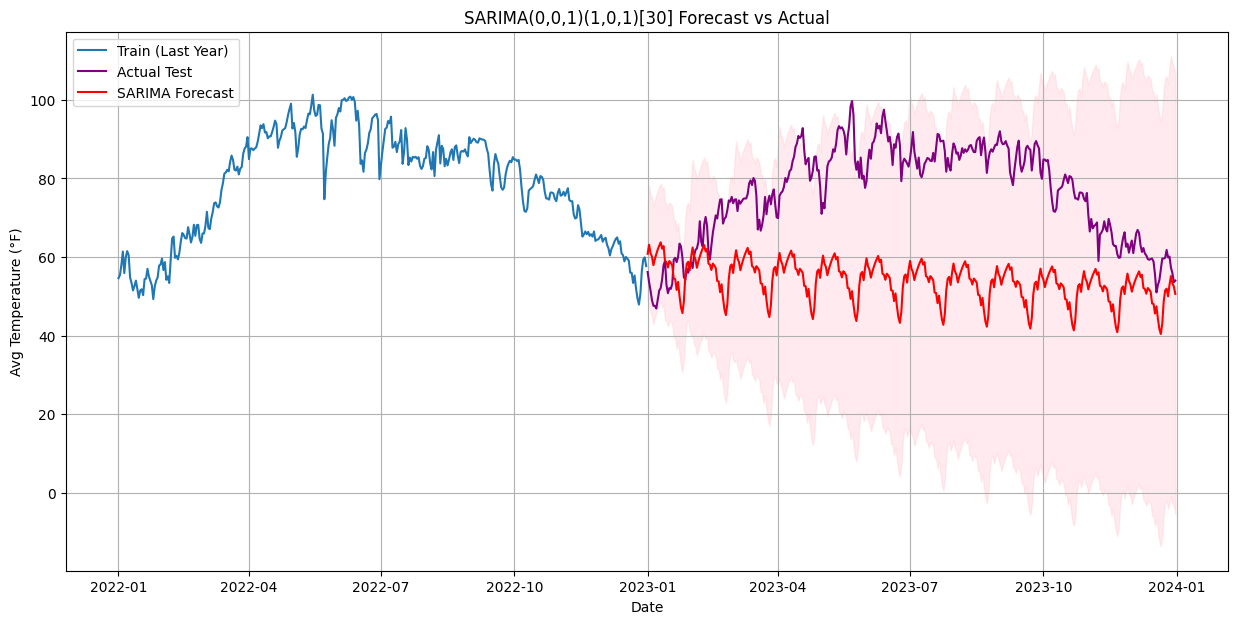

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Split into train and test (using the same 365-day test set as before)
train_sarima = y_continuous[:-365]
test_sarima = y_continuous[-365:]

# Define and fit the SARIMA model with monthly seasonality (s=30)
sarima_model = SARIMAX(train_sarima,
                       order=(0, 0, 1),
                       seasonal_order=(1, 0, 1, 30),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit(disp=False)

# Forecast on the test set
sarima_forecast = sarima_results.get_forecast(steps=365)
sarima_mean = sarima_forecast.predicted_mean
sarima_conf_int = sarima_forecast.conf_int()

# Calculate metrics
sarima_rmse = np.sqrt(mean_squared_error(test_sarima, sarima_mean))
print(f"SARIMA(0,0,1)(1,0,1)[30] RMSE: {sarima_rmse:.2f}")

# Plotting results
plt.figure(figsize=(15, 7))
plt.plot(train_sarima.index[-365:], train_sarima[-365:], label='Train (Last Year)')
plt.plot(test_sarima.index, test_sarima, label='Actual Test', color='purple')
plt.plot(sarima_mean.index, sarima_mean, label='SARIMA Forecast', color='red')
plt.fill_between(sarima_conf_int.index,
                 sarima_conf_int.iloc[:, 0],
                 sarima_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA(0,0,1)(1,0,1)[30] Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculate metrics for SARIMA model
sarima_rmse = np.sqrt(mean_squared_error(test_sarima, sarima_mean))

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

sarima_mape = mean_absolute_percentage_error(test_sarima, sarima_mean)

print(f"SARIMA(0,0,1)(1,0,1)[30] RMSE on Test Set: {sarima_rmse:.2f}")
print(f"SARIMA(0,0,1)(1,0,1)[30] MAPE on Test Set: {sarima_mape:.2f}%")

SARIMA(0,0,1)(1,0,1)[30] RMSE on Test Set: 26.04
SARIMA(0,0,1)(1,0,1)[30] MAPE on Test Set: 28.87%
